Accession: ADI87650
download: s3://pmc-oa-opendata/PMC13153714.1/PMC13153714.1.txt to data/accessions/ADI87650/library/accession_lit/PMC13153714.1.txt
download: s3://pmc-oa-opendata/PMC13142089.1/PMC13142089.1.txt to data/accessions/ADI87650/library/accession_lit/PMC13142089.1.txt
ClassifyHostMetadata: host='Enterobacteriales' taxonomic_level='family' host_reasoning="The metadata explicitly states 'host': 'Enterobacteriales'." host_found=True


download: s3://pmc-oa-opendata/PMC13126132.1/PMC13126132.1.txt to data/accessions/ADI87650/library/host_lit/PMC13126132.1.txt
download: s3://pmc-oa-opendata/PMC12994799.1/PMC12994799.1.txt to data/accessions/ADI87650/library/host_lit/PMC12994799.1.txt
download: s3://pmc-oa-opendata/PMC12883358.1/PMC12883358.1.txt to data/accessions/ADI87650/library/host_lit/PMC12883358.1.txt
download: s3://pmc-oa-opendata/PMC12955436.1/PMC12955436.1.txt to data/accessions/ADI87650/library/host_lit/PMC12955436.1.txt
ClassifyThermalMetadataVote: thermal_range='Non

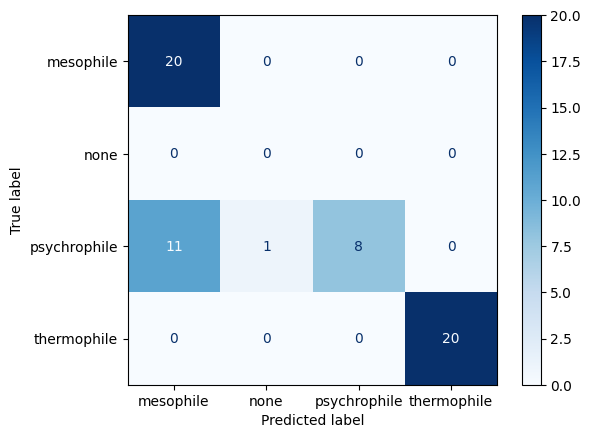

Total Duration: 142.82 minutes


/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [2]:
from langchain_ollama import ChatOllama
############################################################################################################################################################
# DEMOCRATIC WORKFLOW
############################################################################################################################################################
from sklearn.metrics import classification_report
from tools import ConfusionMatrix
from main import DemocraticTMP
import pandas as pd
import json
import matplotlib.pyplot as plt

# State rows to keep
keep=['accession', 'thermal_range', 'thermal_source', 'thermal_reasoning', 'thermal_confidence', 'thermal_source', 'inference_type', 'thermal_paper', 'host','taxonomic_level','host_reasoning','host_confidence','host_source','host_paper','duration', 'nodes', 'timings']

#Getting accessions
ex_df=pd.read_csv('data/example/expanded_example_data.csv')
accessions=ex_df['Accession']


all_df = pd.DataFrame()

# Classifying each accession
preds=[]
for acc in accessions:
    print(f'Accession: {acc}')
    result = DemocraticTMP(acc, "gemma4:e4b")

    votes=result.get('thermal_votes')
    highest_key = max(votes, key=votes.get)
    preds.append(highest_key)
    print(f'\n{acc}: {highest_key}')
    df = pd.DataFrame([result])

    # serialize complex fields
    df["metadata"] = df["metadata"].apply(json.dumps)
    df["timings"] = df["timings"].apply(json.dumps)
    df["nodes"] = df["nodes"].apply(json.dumps)

    all_df = pd.concat([all_df, df], ignore_index=True)



all_df["thermal_range"] = preds

all_df.to_csv('results/democratic_result.csv', index=False)

# Create confusion matrix
actual=ex_df['Thermal Range']
pred=all_df['thermal_range']

#Clean out None
actual_clean = actual.fillna("unknown")
pred_clean = pred.fillna("unknown")

plot=ConfusionMatrix(actual_clean, pred_clean)
plot.plot(cmap='Blues')
plt.savefig('results/democratic_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# Total duration
import pandas as pd
df=pd.read_csv('results/democratic_result.csv')
total_duration=0
for i in df['duration']:
    total_duration+=i
print(f'Total Duration: {round((total_duration/60),2)} minutes')

# Get the classification report
classification_report=classification_report(actual_clean, pred_clean)

with open('results/democratic_classification_report.txt', 'w') as f:
    f.write(classification_report)
    f.write(f'\n\n Total Duration: {round((total_duration/60),2)} minutes')


In [11]:
df[['accession','thermal_range','thermal_votes']]

,accession,thermal_range,thermal_votes
0,ADI87650,mesophile,"{'mesophile': 2, 'thermophile': 0, 'psychrophi..."
1,WXH46553,mesophile,"{'mesophile': 3, 'thermophile': 0, 'psychrophi..."
2,WRQ14408,mesophile,"{'mesophile': 2, 'thermophile': 0, 'psychrophi..."
3,XYW65533,mesophile,"{'mesophile': 3, 'thermophile': 0, 'psychrophi..."
4,SNQ28030,mesophile,"{'mesophile': 2, 'thermophile': 0, 'psychrophi..."
5,NP_049775,mesophile,"{'mesophile': 1, 'thermophile': 0, 'psychrophi..."
6,NP_049787,mesophile,"{'mesophile': 1, 'thermophile': 0, 'psychrophi..."
7,YP_001956829,mesophile,"{'mesophile': 1, 'thermophile': 0, 'psychrophi..."
8,AAC18470,mesophile,"{'mesophile': 2, 'thermophile': 0, 'psychrophi..."
9,NP_046847,mesophile,"{'mesophile': 2, 'thermophile': 0, 'psychrophi..."


In [54]:
from langchain_ollama import ChatOllama
from pydantic import BaseModel
import os

class TestOutput(BaseModel):
    classification: str
    reasoning: str

organism='Shewanella phage SppYZU05'

papers=os.listdir('data/accessions/YP_009790347/library/accession_lit')


with open(f'data/accessions/YP_009790347/library/accession_lit/{papers[0]}') as f:
    paper_text=f.read()

llm=ChatOllama(model='gemma4:e4b',
               reasoning=False,
               temperature=0.0)
llm=llm.with_structured_output(TestOutput)

prompt = f"""You are an academic librarian
You are responsible for filtering our irrelevant literature.
Does paper mention temperature ranges for the horganism in question??
Paper: {paper_text}
Organism: {organism}

OUTPUT RULES:
Only return an answer of True or False
"""

out=llm.invoke(prompt)
out

TestOutput(classification='True', reasoning='The paper mentions the application of the phage cocktail in chilled catfish matrices, testing inhibition at both 25\u202f°C and 4\u202f°C, and evaluating fillet quality at both 4\u202f°C and 25\u202f°C. These are temperature conditions relevant to the organisms/phages in the context of biopreservation.')

In [44]:
from langchain_ollama import ChatOllama
from pydantic import BaseModel
import os

class SumOutput(BaseModel):
    summary: str

papers=os.listdir('data/accessions/YP_009790347/library/accession_lit')


with open(f'data/accessions/YP_009790347/library/accession_lit/{papers[0]}') as f:
    paper_text=f.read()

llm=ChatOllama(model='gemma4:e4b',
               reasoning=False,
               temperature=0.0)
llm=llm.with_structured_output(SumOutput)


prompt = f"""
You are an expert microbiologist specialising in microbial physiology.
Your task is to analyse the following scientific paper and produce a concise, evidence-focused summary for downstream thermal classification.

PAPER:
{paper_text}

INSTRUCTIONS:
Focus primarily on information related to temperature and growth conditions.
Extract and summarise:
- Optimal growth temperature
- Growth temperature range
- Survival temperature range
- Incubation conditions
- Environmental source/habitat
- Any mention of:
  - thermophilic adaptation
  - psychrophilic adaptation
  - mesophilic growth
  - heat tolerance
  - cold tolerance
  - enzymes adapted to temperature
  - membrane adaptations
  - thermal stress responses

Also include:
- Whether the organism was isolated from an extreme environment
- Any explicit classification given by the authors
  (e.g. “moderately thermophilic”, “psychrotolerant”, “mesophile”)

IMPORTANT:
- Do not state what is missing, just summarise what is there, only the importsnt details are needed for downstream analysis

OUTPUT FORMAT:
Organism:
[organism name]

Thermal Evidence:
- [bullet points with temperature findings]

Environmental Context:
- [habitat/source]


Concise Summary:
[~250-400 word evidence-focused summary]

"""

out=llm.invoke(prompt)
summarised_paper=out.summary
summarised_paper

'Organism:\nShewanella baltica and Shewanella putrefaciens\n\nThermal Evidence:\n- Growth inhibition observed at both 25 °C and 4 °C.\n- Reduction in total viable counts observed after 1 day at 25 °C and 10 days at 4 °C.\n\nEnvironmental Context:\n- Chilled fresh fish (Ictalurus punctatus) matrices.\n\nConcise Summary:\nThis study focuses on the spoilage bacteria *Shewanella baltica* and *Shewanella putrefaciens*, which are implicated in the spoilage of chilled fresh fish. The research utilized bacteriophages as a biopreservation tool against these spoilage organisms. \n\nRegarding thermal characteristics, the study explicitly tested the efficacy of the phage cocktail (SPMIX3-156) under refrigeration conditions, demonstrating partial inhibition of bacterial growth in catfish muscle juice at both 25 °C and 4 °C. Furthermore, the biopreservative effect was evaluated over extended periods, showing significant reduction in total viable counts after 1 day at 25 °C and notably after 10 days 

In [45]:
from langchain_ollama import ChatOllama
from pydantic import BaseModel
import os

class TestOutput(BaseModel):
    classification: str
    reasoning: str


llm=ChatOllama(model='gemma4:e4b',
               reasoning=False,
               temperature=0.0)
llm=llm.with_structured_output(TestOutput)

prompt = f"""You are a microbiology expert
Is this paper about a psychrophile, mesophile or thermophile?
Paper: {summarised_paper}

OUTPUT RULES:
Only return an answer of thermophile, mesophile or psychrophile or None if you cannot confidently say
"""

out=llm.invoke(prompt)
out

TestOutput(classification='psychrophile', reasoning="Although the paper does not explicitly state the optimal growth temperature, the environmental context (spoilage of chilled fresh fish) and the observed growth inhibition/reduction in viable counts at 4 °C (refrigeration) strongly suggest that the organisms are adapted to, and active in, cold environments. The summary explicitly uses the term 'psychrotrophic range typical of chilled food storage.' While 'psychrotrophic' is a broader term (meaning they grow well at refrigeration temperatures but may prefer warmer temperatures), in the context of the provided options (psychrophile, mesophile, thermophile), the evidence points most strongly toward a psychrophilic or psychrotrophic lifestyle, making 'psychrophile' the most appropriate classification based on the provided context.")

In [ ]:
# OKay nice managed to flip a misclassification in both the fast and democratic version. Now need to flesh it out into a full graph and refine the state.